In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path
from typing import List

In [2]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")

# Example: print or pass them into other analysis
# print(core_processed_files)


In [3]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in core_processed_files}
flights_ams = {extract_flight_number(f) for f in dry_neph_files}
flights_sp2 = {extract_flight_number(f) for f in sp2_files}
flights_neph = {extract_flight_number(f) for f in ams_files}
flights_sum = {extract_flight_number(f) for f in flight_sum_files}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in core_processed_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in ams_files if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in sp2_files if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in dry_neph_files if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in flight_sum_files if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14


In [4]:
def relative_hum_calc(ds_nc):
    
    # Extract the dew point and time
    T_dew_K = ds_nc['TDEW_GE']  # Dew point temperature in Kelvin
    time = ds_nc['Time']  # Time variable
    # Extract the True air temperature and time
    T_air_K = ds_nc['TAT_DI_R']  # True air temperature in Kelvin with shape (20998, 32)
    
    # Convert 'Time' to a pandas datetime index for resampling
    # Ensure the 'Time' variable is in seconds or a similar time unit that pandas can work with
    time_index = pd.to_datetime(time.values, unit='s')
    
    T_dew_flat = T_dew_K.values.flatten()
    time_flat_dew = time_index.repeat(T_dew_K.shape[1])  # Repeat the time values for each frequency (4Hz)
    
    
    # Create a pandas DataFrame for easier resampling
    df = pd.DataFrame({'Time': time_flat_dew, 'TDEW_GE': T_dew_flat})
    
    # Resample the data by 1 minute and calculate the mean for each interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Convert the resampled dew point temperature back to an xarray
    T_dew_resampled = xr.DataArray(df_resampled['TDEW_GE'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})
    
    # Step 2: Create a pandas DataFrame for resampling
    # Flatten the TAT_DI_R array to make it 1D for DataFrame construction
    T_air_flat = T_air_K.values.flatten()
    time_flat_air = time_index.repeat(T_air_K.shape[1])  # Repeat the time values for each frequency (32Hz)
    
    # Create a DataFrame with the flattened arrays
    df = pd.DataFrame({'Time': time_flat_air, 'TAT_DI_R': T_air_flat})
    
    # Step 3: Resample the data by 1 minute and compute the mean for each time interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Step 4: Convert back to xarray
    T_air_resampled = xr.DataArray(df_resampled['TAT_DI_R'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})

    # Convert from Kelvin to Celsius
    T_dew_resampled_C = T_dew_resampled - 273.15
    
    # Convert from Kelvin to Celsius
    T_air_resampled_C = T_air_resampled - 273.15
    
    # Convert to Celsius
    T_dew_C = T_dew_resampled_C
    T_air_C = T_air_resampled_C
    
    # Calculate relative humidity using the Magnus formula
    RH = 100 * (np.exp((17.625 * T_dew_C) / (243.04 + T_dew_C)) /
                np.exp((17.625 * T_air_C) / (243.04 + T_air_C)))


    return RH

In [5]:
ds_psap = xr.open_dataset(filtered_nc[4])
RH = relative_hum_calc(ds_psap)

/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


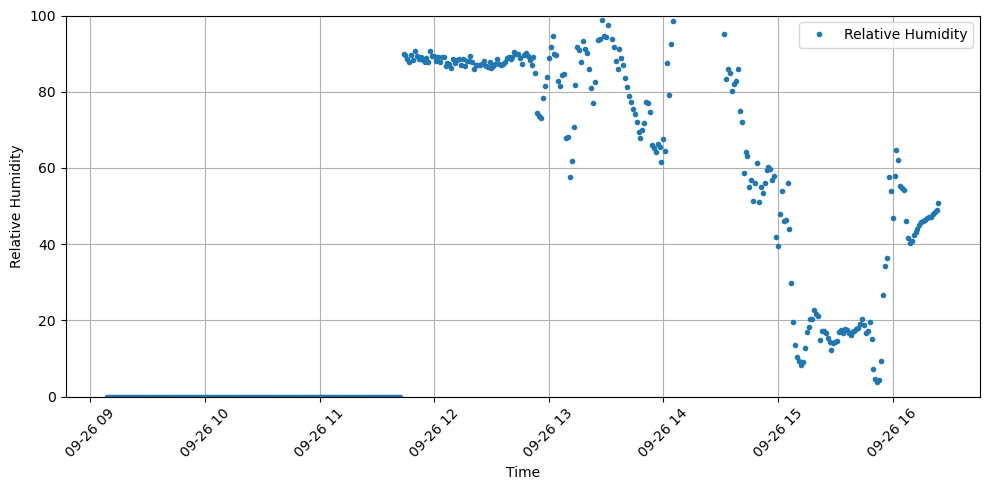

In [6]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
#plt.plot(ds_wet_matched['Time'], ds_wet_matched['TSC_BLUU'],label='Wet Nephelometer', marker='.',linewidth=0)
plt.plot(RH['time'], RH,label='Relative Humidity', marker='.',linewidth=0)

plt.xlabel('Time')
plt.ylabel(r'Relative Humidity')
plt.ylim(0,100)
#plt.xlim(ds_wet_matched['Time'],ds_wet_matched['Time'])
plt.xticks(rotation=45)
plt.grid()
plt.legend()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

In [7]:
alpha = 0.15
fh = (1-(RH)/100)**(-alpha)

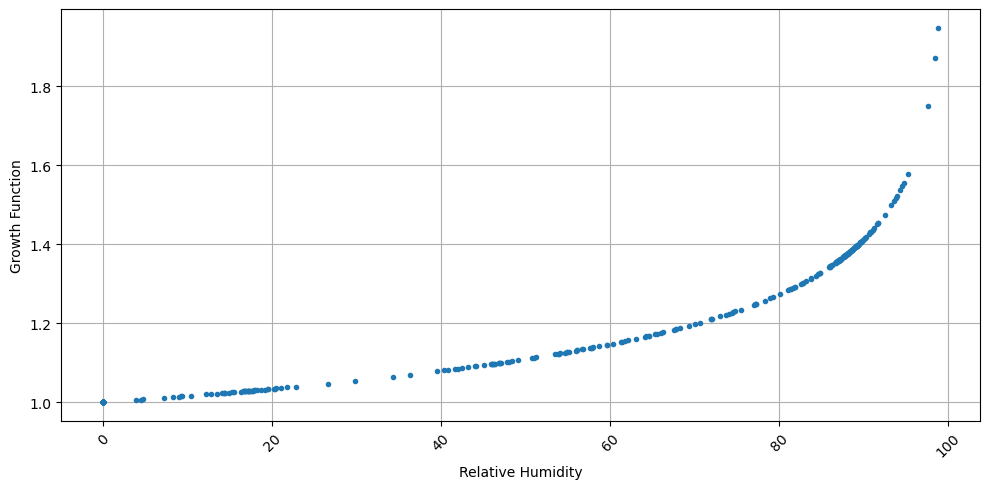

In [8]:

plt.figure(figsize=(10, 5))

plt.plot(RH, fh, marker='.',linewidth=0)

plt.xlabel('Relative Humidity')
plt.ylabel('Growth Function')

plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

# Show the plot
plt.show()

/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)
/srv/conda/envs/

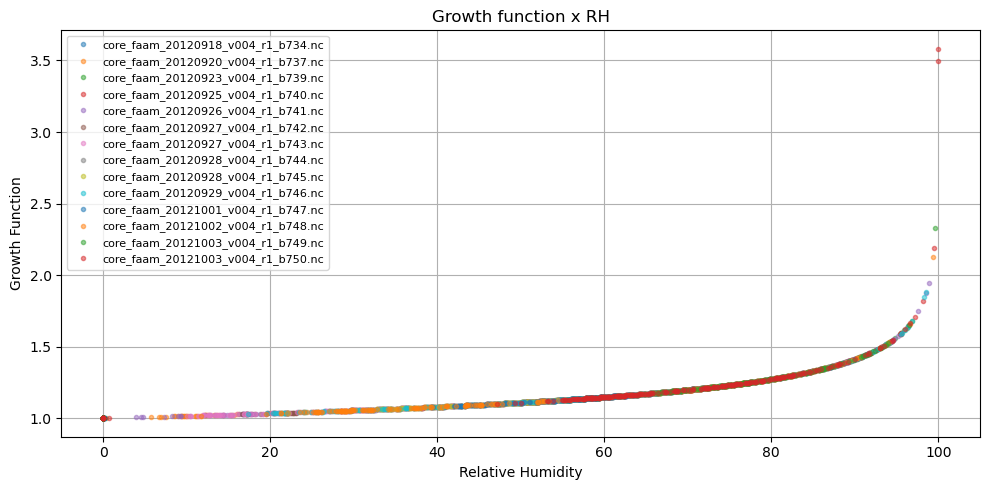

In [9]:
# List to store results
results_fh = []

plt.figure(figsize=(10, 5))

alpha = 0.15 


# Iterate over all matching flights
for nc_file in filtered_nc:

    ds_psap = xr.open_dataset(nc_file)
    RH = relative_hum_calc(ds_psap)

    fh = (1-(RH)/100)**(-alpha)


    # Plot
    plt.plot(
        RH,
        fh,
        marker=".",
        linewidth=0,
        alpha=0.5,
        label=nc_file.split("/")[-1]  # Optional: show filename as label
    )

    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"

    # Compute the mean, handling cases where the list might be empty
    mean_growth_func = np.nanmean(fh) 
    std_mean_growth_func = np.nanstd(fh) 
    mean_std = std_mean_growth_func/np.sqrt(len(fh))

    # Store results in a list
    results_fh.append({
        "flight": flight_number,
        "mean_growth_func": mean_growth_func,
        "std_mean_growth_func": std_mean_growth_func,
        "mean_std": mean_std,
        "N": len(fh)
    })

# Formatting
plt.xlabel('Relative Humidity')
plt.ylabel('Growth Function')
#plt.ylim(-5,75)
#plt.xlim(0,400)
plt.grid()
plt.legend(loc="best", fontsize=8)
plt.title("Growth function x RH")
plt.tight_layout()
plt.show()

In [10]:
# Print results
for res in results_fh:
    print(f"Flight {res['flight']}: {res['mean_growth_func']:.3f}")

Flight b734: 1.117
Flight b737: 1.102
Flight b739: 1.177
Flight b740: 1.186
Flight b741: 1.146
Flight b742: 1.098
Flight b743: 1.104
Flight b744: 1.095
Flight b745: 1.138
Flight b746: 1.168
Flight b747: 1.081
Flight b748: 1.171
Flight b749: 1.177
Flight b750: 1.217


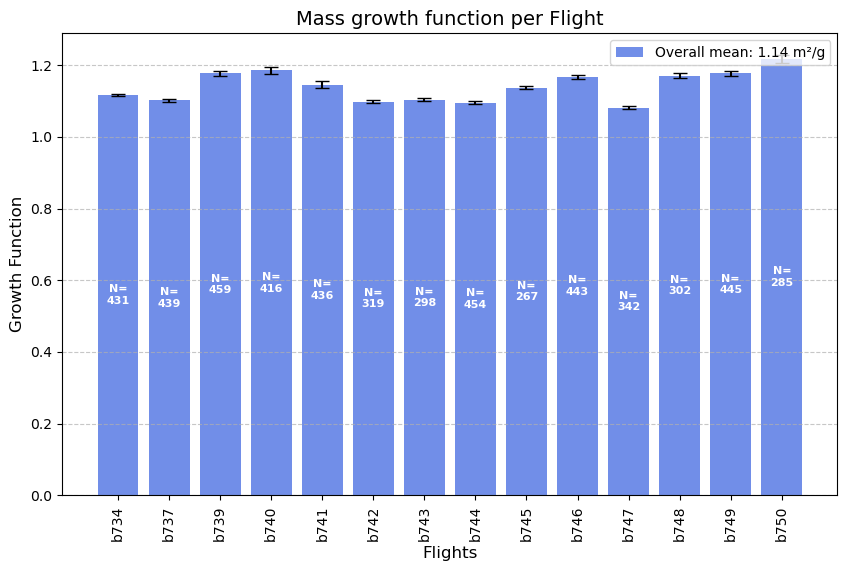

In [11]:
# Extract flight numbers, mean values, standard deviation, and N
flight_numbers = [res["flight"] for res in results_fh]
mean_mass_absorption_eff_g_values = [res["mean_growth_func"] for res in results_fh]
mean_std_values = [res["mean_std"] for res in results_fh]  # Error bars
n_values = [res["N"] for res in results_fh]  # Number of measurements

# Compute overall mean of the means
overall_mean = np.mean(np.array(mean_mass_absorption_eff_g_values)[np.isfinite(mean_mass_absorption_eff_g_values)])
#overall_mean = np.nanmean(mean_mass_absorption_eff_g_values)  # use nanmean in case of NaNs

# Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(
    flight_numbers,
    mean_mass_absorption_eff_g_values,
    yerr=mean_std_values,  # Add error bars
    capsize=5,
    color='royalblue',
    alpha=0.75,
    label=f'Overall mean: {overall_mean:.2f} m²/g'  # Add to legend
)

# Labels and title
plt.xlabel("Flights", fontsize=12)
plt.ylabel("Growth Function", fontsize=12)
plt.title("Mass growth function per Flight", fontsize=14)
plt.xticks(rotation=90)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text inside the bars to show N
for bar, n in zip(bars, n_values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f"N=\n{n}",
        ha='center',
        va='center',
        fontsize=8,
        color='white',
        fontweight='bold'
    )

# Add legend
plt.legend(loc='upper right')

# Save the plot
plt.show()